Employee Salary Prediction using Regression Models

In [2]:
#we imports all the required libraries first
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import r2_score, mean_squared_error

df=pd.read_csv("employee_salary.csv")
df

,age,experience,education,job_level,department,job_role,performance_rating,projects_completed,certifications,weekly_hours,...,team_size,leadership_score,skill_match,years_in_role,promotion_count,employment_type,location_type,company_size,job_satisfaction,salary
0,24,7,Masters,Junior,Finance,Manager,1,2,3,56,...,3,7.912020,7.832917,3,1,Full-time,Urban,Medium,4,57545.519834
1,53,2,Bachelors,Junior,IT,Clerk,4,18,3,50,...,11,4.362620,6.004963,6,0,Full-time,Rural,Medium,4,51024.575364
2,43,14,Masters,Mid,IT,Engineer,1,19,1,44,...,2,8.641647,8.726149,2,3,Part-time,Semi-Urban,Large,2,91913.026252
3,32,3,Bachelors,Junior,Finance,Engineer,5,4,2,51,...,1,6.099317,5.102624,0,2,Full-time,Urban,Small,1,56080.465957
4,33,19,Masters,Senior,Finance,Engineer,5,7,9,31,...,13,4.301078,7.288423,5,3,Contract,Semi-Urban,Medium,3,99002.186129
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,32,27,PhD,Senior,Sales,Analyst,1,8,4,55,...,13,5.013422,4.636595,8,0,Part-time,Rural,Medium,1,110410.336600
1496,50,3,Masters,Junior,Finance,Analyst,2,19,8,30,...,6,7.982278,8.644854,5,4,Full-time,Urban,Large,1,62997.102123
1497,47,22,Masters,Junior,Finance,Manager,5,14,3,45,...,7,1.252433,7.914028,4,0,Part-time,Semi-Urban,Small,4,106553.266077
1498,52,7,Masters,Senior,Sales,Analyst,1,14,6,42,...,3,3.623887,2.663091,6,0,Full-time,Urban,Medium,1,44807.596340


In [4]:
#now we check the simple structre and statistics of dataset.
print(df.head())
print(df.info())
print(df.describe())
print(df.shape)
print(df.ndim)

   age  experience  education job_level department  job_role  \
0   24           7    Masters    Junior    Finance   Manager   
1   53           2  Bachelors    Junior         IT     Clerk   
2   43          14    Masters       Mid         IT  Engineer   
3   32           3  Bachelors    Junior    Finance  Engineer   
4   33          19    Masters    Senior    Finance  Engineer   

   performance_rating  projects_completed  certifications  weekly_hours  ...  \
0                   1                   2               3            56  ...   
1                   4                  18               3            50  ...   
2                   1                  19               1            44  ...   
3                   5                   4               2            51  ...   
4                   5                   7               9            31  ...   

   team_size  leadership_score  skill_match  years_in_role  promotion_count  \
0          3          7.912020     7.832917            

In [5]:
#then we remove duplicates and also handling missing values
a = df.drop_duplicates()
print(a)
print(df.isnull().sum())
d = df.dropna()
print(d)


     age  experience  education job_level department  job_role  \
0     24           7    Masters    Junior    Finance   Manager   
1     53           2  Bachelors    Junior         IT     Clerk   
2     43          14    Masters       Mid         IT  Engineer   
3     32           3  Bachelors    Junior    Finance  Engineer   
4     33          19    Masters    Senior    Finance  Engineer   
..   ...         ...        ...       ...        ...       ...   
295   50          17    Masters    Senior         IT   Analyst   
296   27           0        PhD       Mid      Sales     Clerk   
297   24          17    Masters    Junior         HR     Clerk   
298   36           4    Masters    Junior    Finance  Engineer   
299   34          12        PhD    Senior         HR   Analyst   

     performance_rating  projects_completed  certifications  weekly_hours  \
0                     1                   2               3            56   
1                     4                  18          

In [6]:
#outlier detection and removal
Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['salary']>=Q1-1.5*IQR)&(df['salary']<=Q3+1.5*IQR)]
df
print("after removing outliers shape",df.shape)

after removing outliers shape (1500, 21)


In [7]:
#filling numerical columns with mean and categorical columns with mode
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
df

,age,experience,education,job_level,department,job_role,performance_rating,projects_completed,certifications,weekly_hours,...,team_size,leadership_score,skill_match,years_in_role,promotion_count,employment_type,location_type,company_size,job_satisfaction,salary
0,24,7,Masters,Junior,Finance,Manager,1,2,3,56,...,3,7.912020,7.832917,3,1,Full-time,Urban,Medium,4,57545.519834
1,53,2,Bachelors,Junior,IT,Clerk,4,18,3,50,...,11,4.362620,6.004963,6,0,Full-time,Rural,Medium,4,51024.575364
2,43,14,Masters,Mid,IT,Engineer,1,19,1,44,...,2,8.641647,8.726149,2,3,Part-time,Semi-Urban,Large,2,91913.026252
3,32,3,Bachelors,Junior,Finance,Engineer,5,4,2,51,...,1,6.099317,5.102624,0,2,Full-time,Urban,Small,1,56080.465957
4,33,19,Masters,Senior,Finance,Engineer,5,7,9,31,...,13,4.301078,7.288423,5,3,Contract,Semi-Urban,Medium,3,99002.186129
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,32,27,PhD,Senior,Sales,Analyst,1,8,4,55,...,13,5.013422,4.636595,8,0,Part-time,Rural,Medium,1,110410.336600
1496,50,3,Masters,Junior,Finance,Analyst,2,19,8,30,...,6,7.982278,8.644854,5,4,Full-time,Urban,Large,1,62997.102123
1497,47,22,Masters,Junior,Finance,Manager,5,14,3,45,...,7,1.252433,7.914028,4,0,Part-time,Semi-Urban,Small,4,106553.266077
1498,52,7,Masters,Senior,Sales,Analyst,1,14,6,42,...,3,3.623887,2.663091,6,0,Full-time,Urban,Medium,1,44807.596340


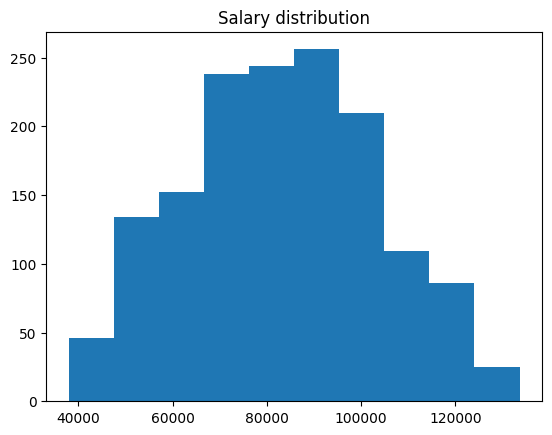

In [8]:
#data visualization
#Histogram
plt.hist(df['salary'])
plt.title("Salary distribution")
plt.show()

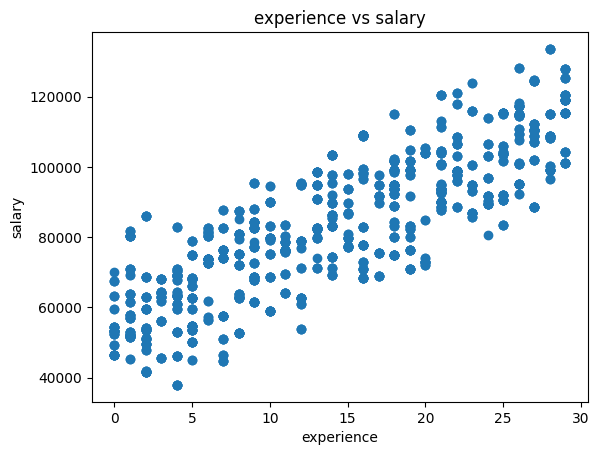

In [9]:
#Scatter plot
plt.scatter(x=df['experience'],y=df['salary'])
plt.xlabel("experience")
plt.ylabel("salary")
plt.title("experience vs salary")
plt.show()

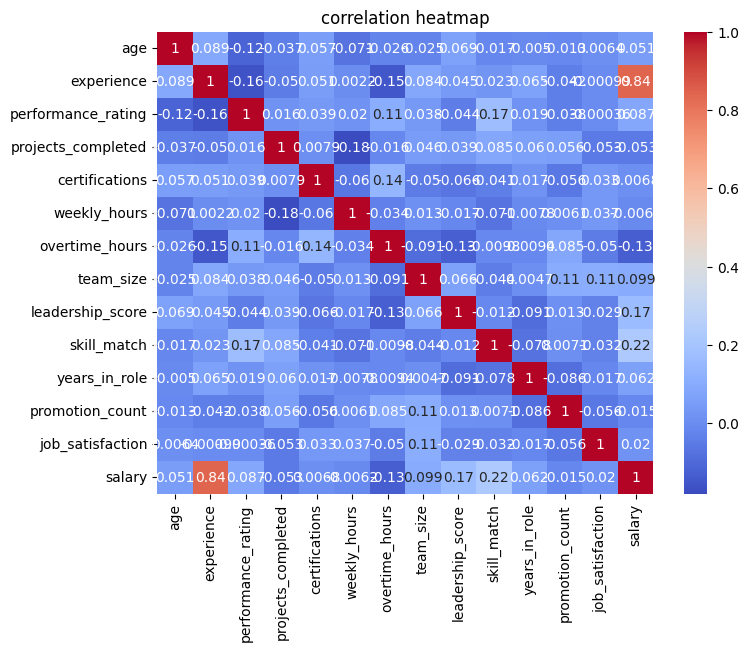

In [10]:
#heatmap
corr=df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("correlation heatmap")
plt.show()

In [11]:
#encoding(categorical data to numerical data)

df = pd.get_dummies(df, drop_first=True)

print("Data After Encoding:")
print(df.head())
print("Final Dataset Shape:", df.shape)

Data After Encoding:
   age  experience  performance_rating  projects_completed  certifications  \
0   24           7                   1                   2               3   
1   53           2                   4                  18               3   
2   43          14                   1                  19               1   
3   32           3                   5                   4               2   
4   33          19                   5                   7               9   

   weekly_hours  overtime_hours  team_size  leadership_score  skill_match  \
0            56               7          3          7.912020     7.832917   
1            50              19         11          4.362620     6.004963   
2            44              18          2          8.641647     8.726149   
3            51               7          1          6.099317     5.102624   
4            31              19         13          4.301078     7.288423   

   ...  department_Sales  job_role_Clerk  job_r

In [12]:
print(df.columns)

Index(['age', 'experience', 'performance_rating', 'projects_completed',
       'certifications', 'weekly_hours', 'overtime_hours', 'team_size',
       'leadership_score', 'skill_match', 'years_in_role', 'promotion_count',
       'job_satisfaction', 'salary', 'education_Masters', 'education_PhD',
       'job_level_Mid', 'job_level_Senior', 'department_HR', 'department_IT',
       'department_Sales', 'job_role_Clerk', 'job_role_Engineer',
       'job_role_Manager', 'employment_type_Full-time',
       'employment_type_Part-time', 'location_type_Semi-Urban',
       'location_type_Urban', 'company_size_Medium', 'company_size_Small'],
      dtype='object')


In [40]:
#feature scaling 
X = df.drop("salary", axis=1)
y = df["salary"]
print(X)
print(y)

      age  experience  performance_rating  projects_completed  certifications  \
0      24           7                   1                   2               3   
1      53           2                   4                  18               3   
2      43          14                   1                  19               1   
3      32           3                   5                   4               2   
4      33          19                   5                   7               9   
...   ...         ...                 ...                 ...             ...   
1495   32          27                   1                   8               4   
1496   50           3                   2                  19               8   
1497   47          22                   5                  14               3   
1498   52           7                   1                  14               6   
1499   48          15                   4                  14               4   

      weekly_hours  overtim

In [18]:
#Normalization and Min-Max scaler
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X)
print(X_std.mean(axis=0))
scaler_mm = MinMaxScaler()
X_mm = scaler_mm.fit_transform(X)
print(X_mm)

[ 1.49213975e-16  4.08562073e-17  0.00000000e+00  8.64493662e-17
 -4.50010399e-17 -2.68822002e-16  9.94759830e-17  9.71075072e-17
  5.21064673e-17 -2.08129810e-16 -6.15803704e-17  1.08949886e-16
  1.06581410e-16  9.47390314e-17  1.65793305e-17  6.86857978e-17
 -5.68434189e-17  3.55271368e-17  0.00000000e+00  2.96059473e-17
 -8.76336041e-17 -8.28966525e-18  2.96059473e-17  5.92118946e-18
  4.14483263e-17 -3.01980663e-17  4.73695157e-17 -8.17124146e-17
  1.18423789e-17]
[[0.07894737 0.24137931 0.         ... 1.         1.         0.        ]
 [0.84210526 0.06896552 0.75       ... 0.         1.         0.        ]
 [0.57894737 0.48275862 0.         ... 0.         0.         0.        ]
 ...
 [0.68421053 0.75862069 1.         ... 0.         0.         1.        ]
 [0.81578947 0.24137931 0.         ... 1.         1.         0.        ]
 [0.71052632 0.51724138 0.75       ... 1.         0.         1.        ]]


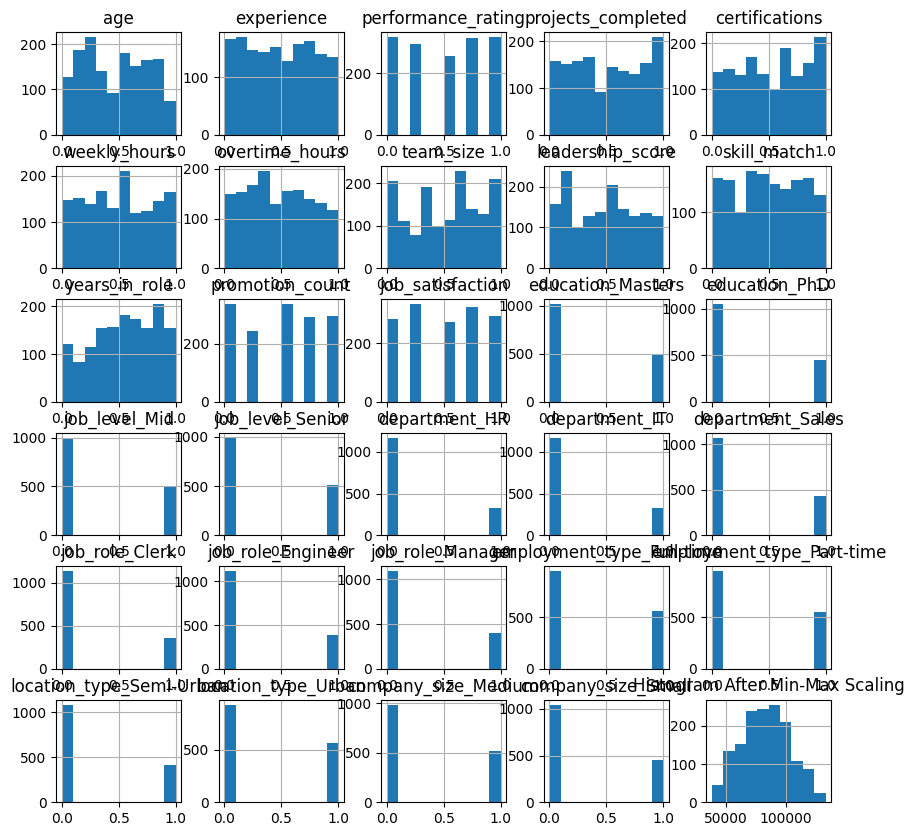

In [22]:
#visualization after Normalization and Min-Max scaler
scaled_df = pd.DataFrame(X_mm, columns=X.columns)
scaled_df['salary'] = y
#histogram
scaled_df.hist(figsize=(10,10))
plt.title("Histogram After Min-Max Scaling")
plt.show()

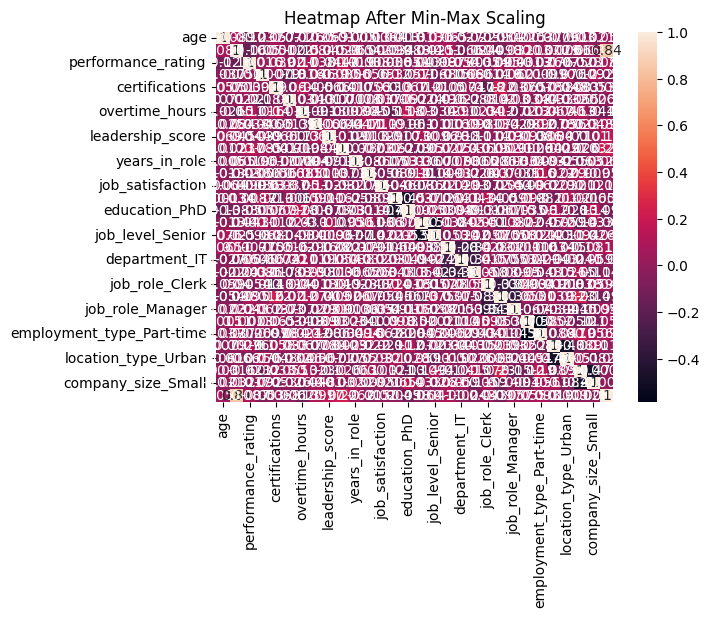

In [23]:
sns.heatmap(scaled_df.corr(), annot=True)
plt.title("Heatmap After Min-Max Scaling")
plt.show()

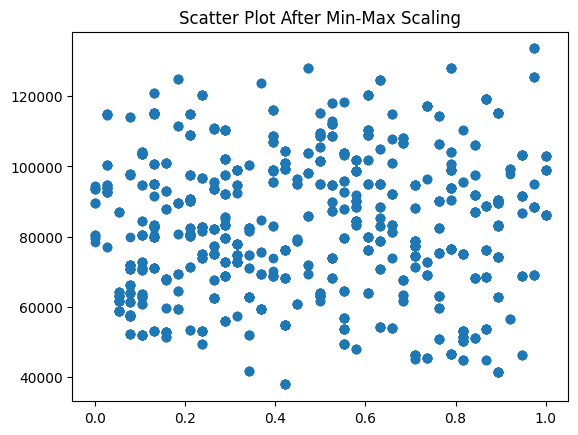

In [24]:
plt.scatter(scaled_df.iloc[:,0], scaled_df['salary'])
plt.title("Scatter Plot After Min-Max Scaling")
plt.show()

In [25]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(X_mm, y, test_size=0.2)


In [39]:
#forward selection
model = LinearRegression()
sfs = SequentialFeatureSelector(model, n_features_to_select=10, direction="forward")

X_train_sfs = sfs.fit_transform(X_train, y_train)
X_test_sfs = sfs.transform(X_test)
print(X_test_sfs)

[[0.20689655 0.75       0.66666667 ... 0.         1.         1.        ]
 [0.10344828 0.25       0.66666667 ... 1.         1.         0.        ]
 [0.5862069  1.         0.27777778 ... 0.         1.         0.        ]
 ...
 [0.17241379 1.         0.5        ... 0.         1.         0.        ]
 [0.79310345 0.25       0.11111111 ... 0.         0.         1.        ]
 [0.06896552 0.         0.05555556 ... 0.         0.         1.        ]]


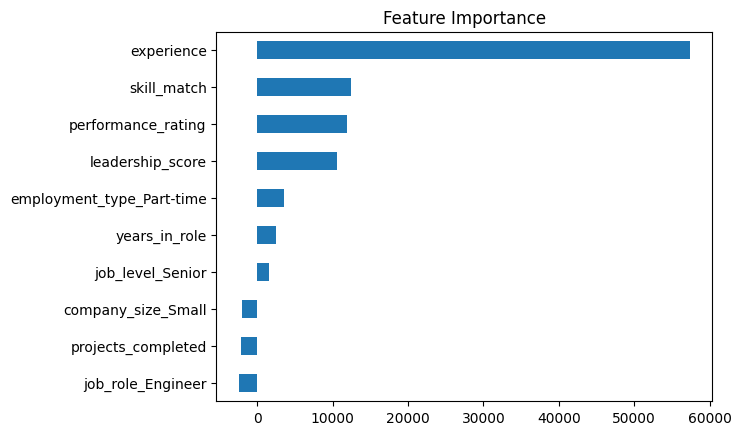

In [50]:
#feature importance
selected_features = X.columns[sfs.get_support()]
importance = pd.Series(lr.coef_,index=selected_features)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [51]:
#training models
#linear regression
lr = LinearRegression()
lr.fit(X_train_sfs, y_train)
pred_lr = lr.predict(X_test_sfs)
print(pred_lr)

[ 75069.38109213  58517.1882037   94279.15205481  79927.63594467
  83940.488103    68818.9457374  110395.18286934  82745.77758711
  92147.87092279  79488.58539947 104276.50292288 110783.78482871
  75677.70434564  97360.49259848 106758.64657732  88063.62653547
 100632.79385338 108734.91722573  71767.41732942 111428.58886883
  50961.23205048  97704.87410766  63151.60820194  88280.14082469
 104755.22780172  81149.99732941 102922.85715545  87875.22576819
  85219.36557055  95742.75422858  97491.16237249  95742.75422858
  72495.89907916  69189.6345649  103618.80665991  61739.98823029
  83149.97293337  50446.54567838  67305.18226807  81149.99732941
  88280.14082469  75069.38109213  62466.24716416 112084.61085607
 113493.55896626  75948.22202323  71830.97549208  61552.86404463
 104907.67174265  58157.81503498  52951.23420945  70605.19666416
  81531.41355458 119314.63303619  68195.3487252  112084.61085607
  84397.4289481   95766.63019281  75677.70434564 111369.69199757
  68195.3487252   97360.4

In [52]:
#ridge regression
ridge = Ridge()
ridge.fit(X_train_sfs, y_train)
pred_ridge = ridge.predict(X_test_sfs)
print(pred_ridge)

[ 75196.51907789  58760.96642309  94200.31122173  79969.90360275
  83924.89496931  68997.39263421 110129.76265382  82763.55170679
  92068.43676478  79568.95645012 104058.77075048 110523.98799245
  75779.72487934  97235.6169567  106588.70082681  88018.9892268
 100450.42385896 108500.28113104  71937.02362009 111183.11153162
  51245.63107261  97521.97423073  63335.87805801  88231.88151695
 104584.72381406  81136.06809696 102726.41115578  87877.24197187
  85202.9673204   95654.61966291  97398.73405996  95654.61966291
  72636.30408403  69359.41974478 103380.82302336  61910.23246442
  83129.25034748  50752.83419649  67437.53893469  81136.06809696
  88231.88151695  75196.51907789  62636.63676376 111847.42468084
 113229.15609437  76033.88782691  71950.55650728  61749.1819621
 104676.15638997  58406.18615162  53244.97140793  70745.18866309
  81558.8245629  118943.93171687  68351.59970735 111847.42468084
  84402.86283667  95701.64064929  75779.72487934 111077.57856128
  68351.59970735  97235.616

In [53]:
#lasso regression
lasso = Lasso()
lasso.fit(X_train_sfs, y_train)
pred_lasso = lasso.predict(X_test_sfs)
print(pred_lasso)

[ 75063.2183003   58517.89980559  94262.28900619  79926.08668545
  83922.14934748  68830.08295493 110400.57743576  82752.29739534
  92153.9343549   79483.31128772 104270.98426363 110771.45929768
  75666.15235589  97356.98063158 106744.34108085  88056.37154028
 100635.59715339 108735.87819978  71757.39964706 111418.62310495
  50987.77163919  97713.13530757  63159.00282408  88271.1789646
 104742.72853128  81154.92989205 102916.45694686  87869.98444616
  85211.77620788  95716.39807785  97487.0432534   95716.39807785
  72487.14637895  69183.51709323 103618.49102171  61752.3221026
  83165.65633131  50461.02748248  67309.55005924  81154.92989205
  88271.1789646   75063.2183003   62484.39045084 112062.30589508
 113480.69106442  75935.18213738  71847.7395615   61575.08292504
 104903.98141734  58160.31066548  52956.37508715  70605.58052601
  81530.54266766 119306.69935503  68205.1705701  112062.30589508
  84392.33472486  95747.9626933   75666.15235589 111361.88114371
  68205.1705701   97356.980

In [54]:
#evaluation
r2_lr = r2_score(y_test, pred_lr)
r2_ridge = r2_score(y_test, pred_ridge)
r2_lasso = r2_score(y_test, pred_lasso)

rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
rmse_ridge = np.sqrt(mean_squared_error(y_test, pred_ridge))
rmse_lasso = np.sqrt(mean_squared_error(y_test, pred_lasso))
#comparison table
results = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso"],
    "R2 Score": [r2_lr, r2_ridge, r2_lasso],
    "RMSE": [rmse_lr, rmse_ridge, rmse_lasso]
})

print(results)

    Model  R2 Score         RMSE
0  Linear  0.809636  8661.171829
1   Ridge  0.809432  8665.812275
2   Lasso  0.809653  8660.789952


In [48]:
#best model 
best_model = results.loc[results["R2 Score"].idxmax()]
print("Best Model:")
print(best_model)

Best Model:
Model             Lasso
R2 Score       0.809653
RMSE        8660.789952
Name: 2, dtype: object


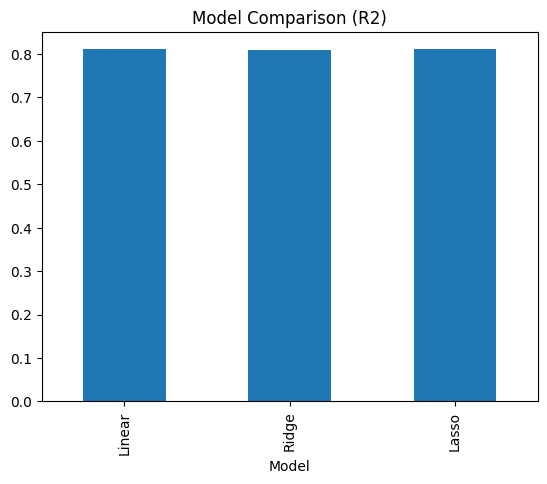

In [55]:
#bar graph of model comparison
results.set_index("Model")["R2 Score"].plot(kind='bar')
plt.title("Model Comparison (R2)")
plt.show()

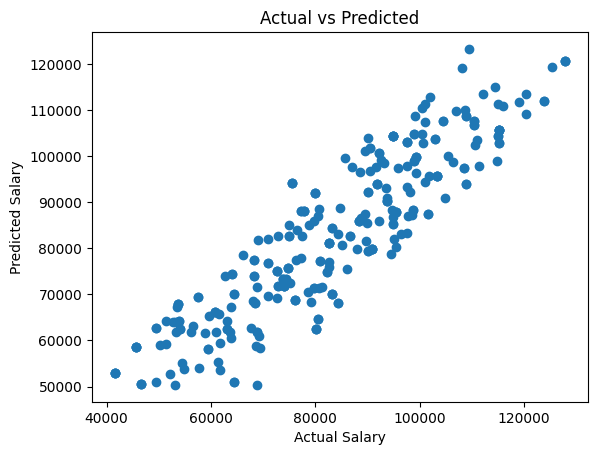

In [56]:
#residual plot
plt.scatter(y_test, pred_lr)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")
plt.show()

In [57]:
#train vs test score
print("Train Score:", lr.score(X_train_sfs, y_train))
print("Test Score:", lr.score(X_test_sfs, y_test))


Train Score: 0.8209817865588648
Test Score: 0.8096361695719018


In [45]:
#prediction
prediction = lr.predict(X_test_sfs[:1])
print("Predicted Salary:", prediction)

Predicted Salary: [75069.38109213]


Conclusion:
The project successfully predicts employee salary using regression models.
Lasso Regression performed best based on R² score and RMSE.
Feature selection and normalization improved model performance.